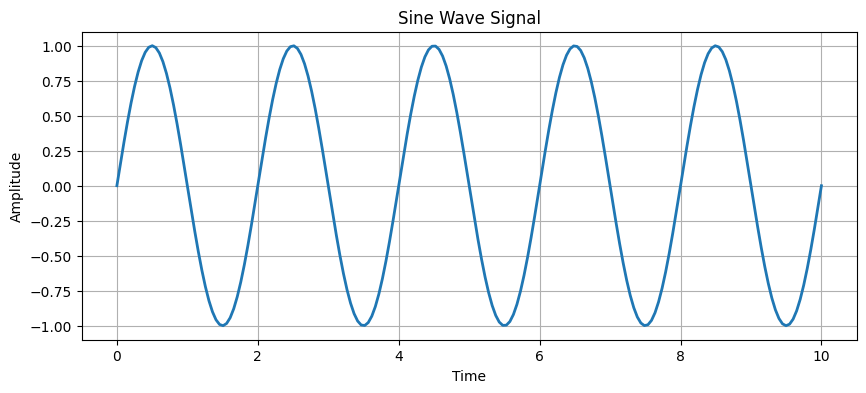

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# time axis
t = np.linspace(0, 10, 200)

# single sine signal
signal1 = np.sin(2 * np.pi * 0.5 * t)

# plot
plt.figure(figsize=(10, 4))
plt.plot(t, signal1, linewidth=2)
plt.title("Sine Wave Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

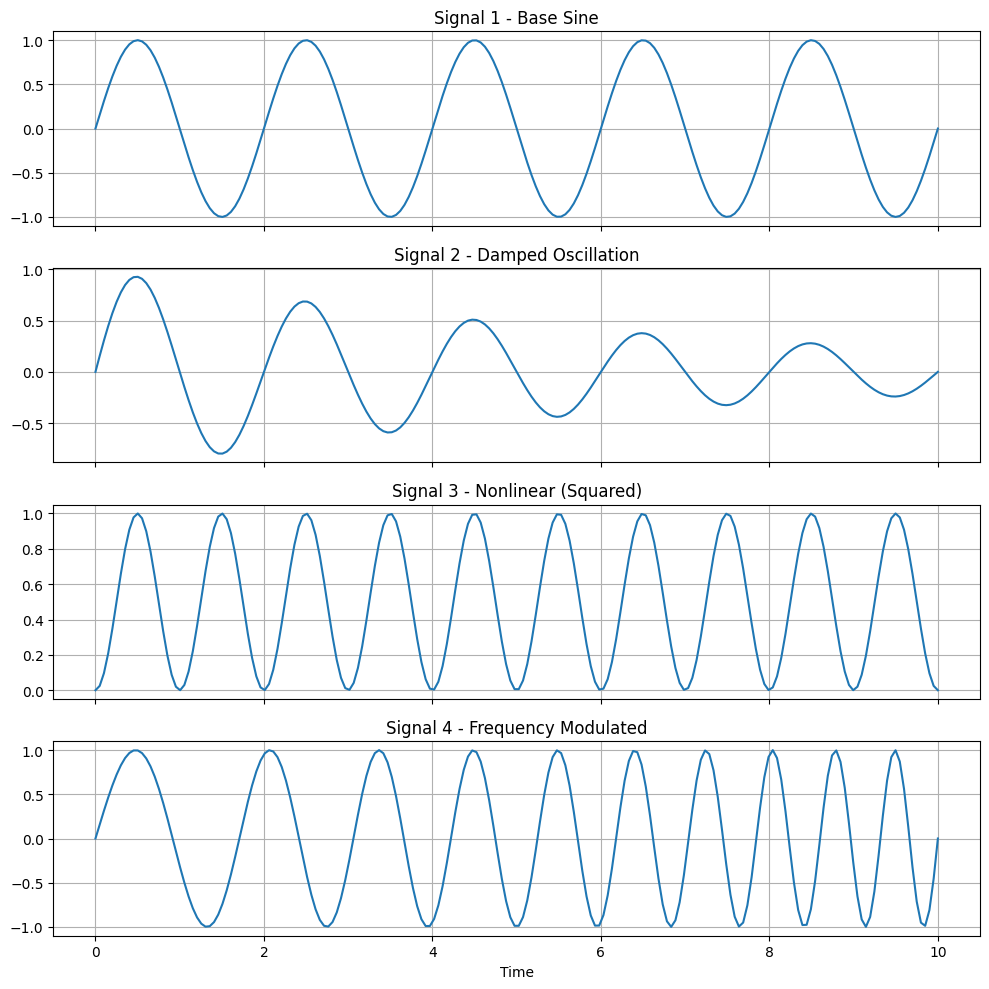

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# time axis
t = np.linspace(0, 10, 200)

# -----------------------------
# Base signal
# -----------------------------
signal1 = np.sin(2 * np.pi * 0.5 * t)

# -----------------------------
# Different derived signals
# -----------------------------

# Signal 2: damped oscillation
signal2 = np.exp(-0.15 * t) * np.sin(2 * np.pi * 0.5 * t)

# Signal 3: nonlinear response
signal3 = np.sin(2 * np.pi * 0.5 * t)**2

# Signal 4: frequency-modulated signal
signal4 = np.sin(2 * np.pi * (0.5 + 0.05*t) * t)

# -----------------------------
# Plot separately
# -----------------------------
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t, signal1)
axs[0].set_title("Signal 1 - Base Sine")
axs[0].grid(True)

axs[1].plot(t, signal2)
axs[1].set_title("Signal 2 - Damped Oscillation")
axs[1].grid(True)

axs[2].plot(t, signal3)
axs[2].set_title("Signal 3 - Nonlinear (Squared)")
axs[2].grid(True)

axs[3].plot(t, signal4)
axs[3].set_title("Signal 4 - Frequency Modulated")
axs[3].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

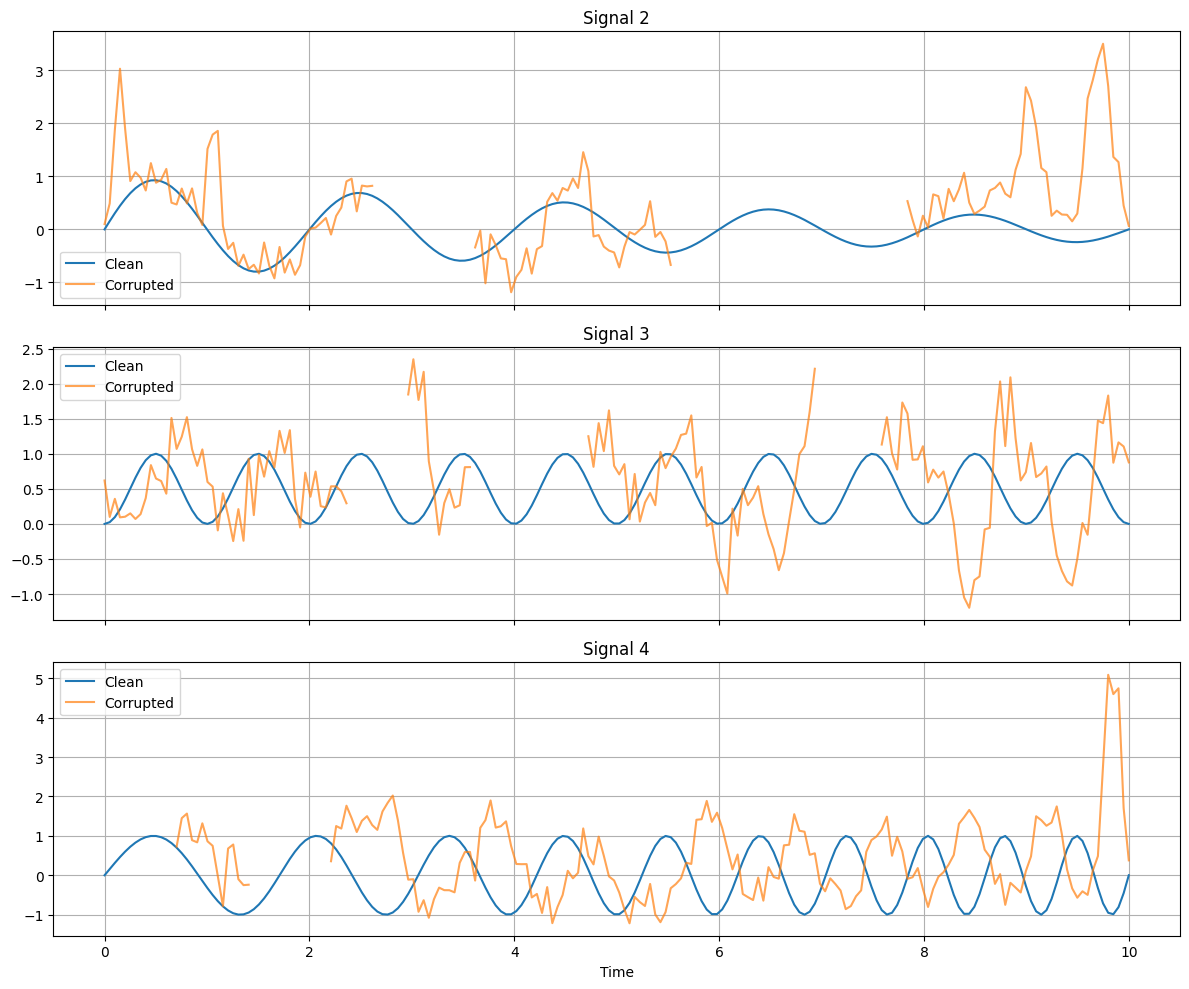

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# time axis
t = np.linspace(0, 10, 200)

# clean signals
signal1 = np.sin(2 * np.pi * 0.5 * t)
signal2 = np.exp(-0.15 * t) * np.sin(2 * np.pi * 0.5 * t)
signal3 = np.sin(2 * np.pi * 0.5 * t)**2
signal4 = np.sin(2 * np.pi * (0.5 + 0.05*t) * t)

# -------------------------------------------------
# HARDER corruption model
# -------------------------------------------------
def corrupt_signal(signal,
                   noise_level=0.25,
                   n_spikes=8,
                   missing_fraction=0.15,
                   delay_steps=3,
                   drift_strength=0.3):

    corrupted = signal.copy()

    N = len(signal)

    # -----------------------------
    # 1. Sensor delay
    # -----------------------------
    corrupted = np.roll(corrupted, delay_steps)

    # -----------------------------
    # 2. Gaussian noise
    # -----------------------------
    corrupted += noise_level * np.random.randn(N)

    # -----------------------------
    # 3. Time-varying noise
    # -----------------------------
    varying_noise = (0.2 + 0.5*np.sin(0.2*t)) * np.random.randn(N)
    corrupted += 0.15 * varying_noise

    # -----------------------------
    # 4. Baseline drift
    # -----------------------------
    drift = drift_strength * np.sin(0.15 * t)
    corrupted += drift

    # -----------------------------
    # 5. Sudden spikes / dips
    # -----------------------------
    for _ in range(n_spikes):

        center = np.random.randint(0, N)
        amp = np.random.uniform(0.8, 2.0)

        if np.random.rand() < 0.5:
            amp *= -1

        width = np.random.randint(2, 8)

        left = max(0, center - width)
        right = min(N, center + width)

        pulse = np.hanning(right - left)

        corrupted[left:right] += amp * pulse

    # -----------------------------
    # 6. Long missing chunks
    # -----------------------------
    n_missing = int(missing_fraction * N)

    for _ in range(3):

        start = np.random.randint(0, N - n_missing//3)
        length = np.random.randint(8, 25)

        corrupted[start:start+length] = np.nan

    # -----------------------------
    # 7. Nonlinear distortion
    # -----------------------------
    corrupted += 0.08 * corrupted**2

    return corrupted


# corrupted signals
signal2_noisy = corrupt_signal(
    signal2,
    noise_level=0.25,
    delay_steps=2
)

signal3_noisy = corrupt_signal(
    signal3,
    noise_level=0.20,
    delay_steps=5
)

signal4_noisy = corrupt_signal(
    signal4,
    noise_level=0.30,
    delay_steps=8
)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

signals = [
    (signal2, signal2_noisy, "Signal 2"),
    (signal3, signal3_noisy, "Signal 3"),
    (signal4, signal4_noisy, "Signal 4")
]

for ax, (clean, noisy, title) in zip(axs, signals):

    ax.plot(t, clean, label="Clean")
    ax.plot(t, noisy, label="Corrupted", alpha=0.7)

    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
import numpy as np

df_signals = pd.DataFrame({
    "time": t,

    "signal2_clean": signal2,
    "signal2_noisy": signal2_noisy,

    "signal3_clean": signal3,
    "signal3_noisy": signal3_noisy,

    "signal4_clean": signal4,
    "signal4_noisy": signal4_noisy,
})

df_signals.to_csv("three_noisy_signals.csv", index=False)
print(df_signals.head())
print(df_signals.columns)

df = pd.read_csv("three_noisy_signals.csv")
print(df.columns)


       time  signal2_clean  signal2_noisy  signal3_clean  signal3_noisy  \
0  0.000000       0.000000       0.100361       0.000000       0.618732   
1  0.050251       0.156033       0.488916       0.024716       0.099272   
2  0.100503       0.305872       1.879454       0.096421       0.357490   
3  0.150754       0.445901       3.031445       0.208026       0.093396   
4  0.201005       0.572803       1.892530       0.348497       0.102693   

   signal4_clean  signal4_noisy  
0       0.000000       0.451642  
1       0.157997            NaN  
2       0.313533            NaN  
3       0.462441            NaN  
4       0.600534            NaN  
Index(['time', 'signal2_clean', 'signal2_noisy', 'signal3_clean',
       'signal3_noisy', 'signal4_clean', 'signal4_noisy'],
      dtype='str')
Index(['time', 'signal2_clean', 'signal2_noisy', 'signal3_clean',
       'signal3_noisy', 'signal4_clean', 'signal4_noisy'],
      dtype='str')


In [33]:
df["global_temperature"] = (
    df["signal2_clean"]
    + df["signal3_clean"]
    + df["signal4_clean"]
) / 3


print(df.head())

       time  signal2_clean  signal2_noisy  signal3_clean  signal3_noisy  \
0  0.000000       0.000000       0.100361       0.000000       0.618732   
1  0.050251       0.156033       0.488916       0.024716       0.099272   
2  0.100503       0.305872       1.879454       0.096421       0.357490   
3  0.150754       0.445901       3.031445       0.208026       0.093396   
4  0.201005       0.572803       1.892530       0.348497       0.102693   

   signal4_clean  signal4_noisy  global_temperature  
0       0.000000       0.451642            0.000000  
1       0.157997            NaN            0.112916  
2       0.313533            NaN            0.238609  
3       0.462441            NaN            0.372123  
4       0.600534            NaN            0.507278  


In [34]:
import numpy as np

# -----------------------------
# Input features
# -----------------------------
X = df[
    ["signal2_noisy", "signal3_noisy", "signal4_noisy"]
].values

# -----------------------------
# Target
# -----------------------------
y = df["global_temperature"].values

# -----------------------------
# reshape
# -----------------------------
X = X[np.newaxis, :, :]            # (1, time, 3)
y = y[np.newaxis, :, np.newaxis]   # (1, time, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1, 200, 3)
y shape: (1, 200, 1)


In [35]:
X_mean = X.mean()
X_std = X.std()

y_mean = y.mean()
y_std = y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

In [37]:
print("X_norm shape:", X_norm.shape)
print("y_norm shape:", y_norm.shape)

print("X_norm mean:", np.mean(X_norm))
print("X_norm std:", np.std(X_norm))

print("y_norm mean:", np.mean(y_norm))
print("y_norm std:", np.std(y_norm))

X_norm shape: (1, 200, 3)
y_norm shape: (1, 200, 1)
X_norm mean: nan
X_norm std: nan
y_norm mean: 3.552713678800501e-17
y_norm std: 1.0
